matrix 1: 3x3 | naive: 0.000019s | numpy: 0.000036s
matrix 2: 6x6 | naive: 0.000054s | numpy: 0.000018s
matrix 3: 12x12 | naive: 0.000452s | numpy: 0.000026s
matrix 4: 24x24 | naive: 0.002892s | numpy: 0.000031s
matrix 5: 48x48 | naive: 0.028618s | numpy: 0.000080s
matrix 6: 96x96 | naive: 0.225461s | numpy: 0.000248s
matrix 7: 192x192 | naive: 1.801351s | numpy: 0.000516s
matrix 8: 384x384 | naive: 15.511280s | numpy: 0.005563s


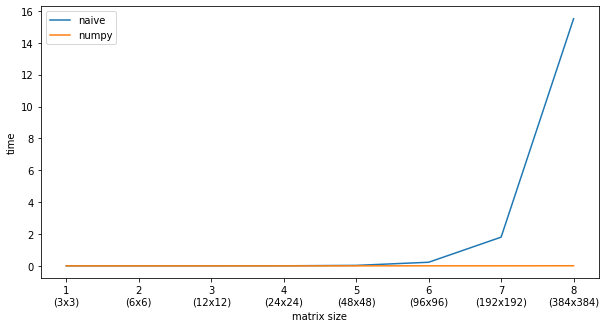

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

def naive_matmul(A, B):
    rows_A = len(A)
    cols_A = len(A[0])
    cols_B = len(B[0])
    
    result = []
    for _ in range(rows_A):
        row = [0.0] * cols_B
        result.append(row)
        
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                result[i][j] += A[i][k] * B[k][j]
    return result

naive_times = []
numpy_times = []
sizes = []

size = 3

for pair in range(8):
    sizes.append(size)

    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    A_list = A_np.tolist()
    B_list = B_np.tolist()

    start = time.time()
    naive_matmul(A_list, B_list)
    naive_times.append(time.time() - start)

    start = time.time()
    np.dot(A_np, B_np)
    numpy_times.append(time.time() - start)

    print(f"matrix {pair+1}: {size}x{size} | naive: {naive_times[-1]:.6f}s | numpy: {numpy_times[-1]:.6f}s")

    size *= 2

x = range(1, 9)
plt.figure(figsize=(10, 5))
plt.plot(x, naive_times, label='naive')
plt.plot(x, numpy_times, label='numpy')

labels = []
for i, s in enumerate(sizes, 1):
    label = f"{i}\n({s}x{s})"
    labels.append(label)

plt.xticks(x, labels)
plt.xlabel("matrix size")
plt.ylabel("time")
plt.legend()
plt.show()